# BAB 4 — Modeling
## Eksperimen pixel-based vs polygon-mean

## 4.1 Mulai dari hasil Tahap 3

**Pertanyaan:** apa yang masuk ke eksperimen (polygon, pixel, feature, yang dibuang)? CSV dibaca, bukan dihitung ulang.

In [2]:
# DATA AKTUAL PROJECT — 4.1 muat artefak Tahap 3 + verifikasi integritas.
import pandas as pd

FEATS = ["B02", "B03", "B04", "B08", "B11", "B12", "NDVI", "NDWI", "NDBI"]
MEANMAP = {f"mean_{b}": b for b in ["B02", "B03", "B04", "B08", "B11", "B12"]}
trp = pd.read_csv("../outputs/tables/training_pixel.csv")
tep = pd.read_csv("../outputs/tables/testing_pixel.csv")
trm = pd.read_csv("../outputs/tables/training_mean.csv")
tem = pd.read_csv("../outputs/tables/testing_mean.csv")
sp = pd.read_csv("../outputs/tables/polygon_split.csv")
exc = pd.read_csv("../outputs/tables/polygon_excluded.csv")
print(f"DATA AKTUAL PROJECT: train_pixel={len(trp)} test_pixel={len(tep)} train_mean={len(trm)} test_mean={len(tem)}")
print(f"DATA AKTUAL PROJECT: polygon train={int((sp['split'] == 'train').sum())} test={int((sp['split'] == 'test').sum())}")
print(f"DATA AKTUAL PROJECT: NaN train_pixel={int(trp[FEATS].isna().sum().sum())} (terbuang bila >0)")
trp = trp.dropna(subset=FEATS).reset_index(drop=True)
print(f"DATA AKTUAL PROJECT: feature_urut = {FEATS}")
print(f"DATA AKTUAL PROJECT: dibuang total={len(exc)} (tidak_valid={int((exc['kategori'] == 'tidak valid').sum())}, kuota={int((exc['kategori'] != 'tidak valid').sum())})")
print(f"DATA AKTUAL PROJECT: irisan FID train-test = {sorted(set(sp[sp['split'] == 'train']['fid']) & set(sp[sp['split'] == 'test']['fid']))}")

DATA AKTUAL PROJECT: train_pixel=40076 test_pixel=11432 train_mean=204 test_mean=52
DATA AKTUAL PROJECT: polygon train=204 test=52
DATA AKTUAL PROJECT: NaN train_pixel=0 (terbuang bila >0)
DATA AKTUAL PROJECT: feature_urut = ['B02', 'B03', 'B04', 'B08', 'B11', 'B12', 'NDVI', 'NDWI', 'NDBI']
DATA AKTUAL PROJECT: dibuang total=2567 (tidak_valid=2055, kuota=512)
DATA AKTUAL PROJECT: irisan FID train-test = []


**Interpretasi 4.1:** masuk eksperimen: train 40.076 pixel / 204 mean; test 11.432 / 52; 204/52 polygon; NaN 0; 2.567 polygon dibuang; irisan FID train-test kosong — syarat perlakuan setara terpenuhi.

## 4.2 Konsep model (penjelasan dulu, baru kode)

**Alur:** vektor feature 9 angka → satu decision tree (aturan ambang berurutan, mis. NIR tinggi + merah rendah cenderung vegetasi) → banyak tree dari bootstrap + subset fitur acak (bagging) → voting mayoritas → satu `class_id`.

```text
CONTOH ILUSTRASI (12 baris uji data coba):
pixel -> [tree1: Sawah] [tree2: Sawah] [tree3: Lahan hijau] -> voting 2-1 -> Sawah
```

### Kartu model (netral; kelebihan/kekurangan singkat)

| Model | Cara kerja | Cenderung kuat saat | Keterbatasan |
|---|---|---|---|
| Random Forest (RF) | Bagging tree + subset fitur, voting | Fitur heterogen, tahan noise | Ratusan tree bisa lambat; dominasi kelas besar |
| ExtraTrees (ET) | Seperti RF, ambang split lebih acak | Biasanya lebih cepat, variansi rendah | Bisa bias tinggi bila terlalu acak |
| LightGBM | Boosting histogram leaf-wise | Cepat, data sedang-besar | Sensitif pada data sangat kecil ( dipakai dengan daun terbatas) |
| SVM RBF | Batas non-linear margin-maksimum | Dimensi sedang, perlu scaling | Mahal pada puluhan ribu sample → subsample training |
| Logistic Regression | Linear + softmax (baseline) | Cepat, tolok ukur | Batas linear saja |

In [25]:
# CONTOH ILUSTRASI — bukan data project: voting RF pada 12 baris mainan.
import numpy as np
from sklearn.ensemble import RandomForestClassifier

Xtoy = np.array([[1, 9], [2, 8], [1, 8], [2, 9], [8, 2], [9, 1], [8, 1], [9, 2], [5, 5], [4, 6], [6, 4], [5, 4]])
ytoy = np.array([1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3])  # 1/2/3 = label mainan
toy = RandomForestClassifier(n_estimators=5, random_state=42).fit(Xtoy, ytoy)
raw = [t.predict([[2, 9]])[0] for t in toy.estimators_]
v = [int(toy.classes_[int(r)]) for r in raw]  # tree mengembalikan kode internal; dipetakan ke label
print(f"CONTOH ILUSTRASI: suara tree = {v} -> prediksi = {toy.predict([[2, 9]])[0]} (aturan mainan, bukan project)")

CONTOH ILUSTRASI: suara tree = [1, 1, 1, 1, 1] -> prediksi = 1 (aturan mainan, bukan project)


## 4.3 Matriks eksperimen (perlakuan setara)

| Metode | Model | Split/Fitur | Tuning | Catatan |
|---|---|---|---|---|
| pixel-based | RF, ExtraTrees, LightGBM, SVM-RBF, LogReg | FID train sama, 9 feature sama | StratifiedGroupKFold(5), group=FID | SVM/LogReg via pipeline scaler fit-per-fold; SVM train subsample 8000 |
| polygon-mean | RF, ExtraTrees, LightGBM, SVM-RBF, LogReg | FID train sama, 9 feature sama | StratifiedGroupKFold(5), group=FID | SVM tanpa subsample (204 baris); scaler sama |

Ruang grid kecil dan sebanding (4/4/4/2/2 kombinasi). Subsample HANYA training, stratified seed 42, dilaporkan. Waktu training dicatat per model.

## 4.4 Ukuran CV(Cross Validation) — ditetapkan SEBELUM melihat hasil

**Metrik pemilihan utama: macro-F1 level polygon dari CV.** Pixel-based: prediksi pixel divoting mayoritas per FID (seri → `class_id` terkecil, deterministik), lalu F1-macro antar polygon. Polygon-mean: langsung dari 1 baris per polygon. Pixel-F1 dilaporkan sebagai tambahan. Dilaporkan mean ± std antar fold. Fold kecil (204 polygon train / 5 → ±40 polygon per validasi) — selisih kecil tidak diklaim bermakna.

In [4]:
# Mesin CV bersama (dipakai kedua metode; agregasi polygon didokumentasikan di 4.4).
import time

import numpy as np
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedGroupKFold

N_SPLITS = 5


def polygon_vote_f1(y_true_px, y_pred_px, groups):
    df = __import__("pandas").DataFrame({"g": groups, "t": y_true_px, "p": y_pred_px})
    yt, yp = [], []
    for _, s in df.groupby("g"):
        yt.append(s["t"].iloc[0])
        vals, cnt = np.unique(s["p"].values, return_counts=True)
        yp.append(int(vals[np.argmax(cnt)]))  # seri -> class_id terkecil (np.unique terurut)
    return float(f1_score(yt, yp, average="macro", zero_division=0)), list(zip(yt, yp))


def run_cv(builder, X, y, groups, param_list, use_groups=True):
    cv = StratifiedGroupKFold(n_splits=N_SPLITS)
    recs, oof = [], {}
    for pi, params in enumerate(param_list):
        fpix, fpol, oof_pairs = [], [], []
        for fold, (tri, vai) in enumerate(cv.split(X, y, groups)):
            est = builder(params)
            t0 = time.time()
            est.fit(X[tri], y[tri])
            dt = time.time() - t0
            pv = est.predict(X[vai])
            fpix.append(float(f1_score(y[vai], pv, average="macro", zero_division=0)))
            f1p, pairs = polygon_vote_f1(y[vai], pv, groups[vai])
            fpol.append(f1p)
            oof_pairs += [(int(a), int(b)) for a, b in pairs]
            recs.append({"params": str(params), "fold": fold, "pixel_f1": fpix[-1], "polygon_f1": fpol[-1], "fit_s": round(dt, 1)})
        oof[pi] = {"params": params, "mean_polygon_f1": float(np.mean(fpol)), "std_polygon_f1": float(np.std(fpol)),
                     "mean_pixel_f1": float(np.mean(fpix)), "pairs": oof_pairs}
    best = max(oof, key=lambda k: oof[k]["mean_polygon_f1"])
    return recs, oof, best

In [9]:
# DATA AKTUAL PROJECT — 4.3a eksperimen pixel-based (40.076 baris train).
import os
import time

import joblib
import numpy as np
import pandas as pd
from IPython.display import display, HTML
from lightgbm import LGBMClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# KONFIGURASI
RANDOM_STATE = 42
os.makedirs("../outputs/models", exist_ok=True)
os.makedirs("../outputs/tables", exist_ok=True)

# DATA
X = trp[FEATS].to_numpy()
y = trp["class_id"].to_numpy()
gr = trp["fid"].to_numpy()
print(f"DATA AKTUAL PROJECT: pixel train n={len(X)} fitur={X.shape[1]} groups={len(np.unique(gr))}")

# SUBSAMPLE SVM (training saja, stratified, seed 42)
rng = np.random.RandomState(RANDOM_STATE)
idx8k = np.concatenate([
    rng.choice(np.where(y == c)[0],
               size=min(8000 // 6 + 200, int((y == c).sum())),
               replace=False)
    for c in [1, 2, 3, 4, 5, 6]
])
rng.shuffle(idx8k)
print(f"DATA AKTUAL PROJECT: subsample SVM {len(X)} -> {len(idx8k)} (aturan: stratified per kelas, seed 42)")

# DEFINISI MODEL
MODELS = {
    "rf": (
        lambda p: RandomForestClassifier(
            n_estimators=300, max_depth=p[0], min_samples_leaf=p[1],
            random_state=RANDOM_STATE, n_jobs=-1),
        [(None, 1), (None, 2), (25, 1), (25, 2)],
    ),
    "et": (
        lambda p: ExtraTreesClassifier(
            n_estimators=300, max_depth=p[0], min_samples_leaf=p[1],
            random_state=RANDOM_STATE, n_jobs=-1),
        [(None, 1), (None, 2), (25, 1), (25, 2)],
    ),
    "lgbm": (
        lambda p: LGBMClassifier(
            n_estimators=300, learning_rate=p[0], num_leaves=p[1],
            random_state=RANDOM_STATE, verbose=-1),
        [(0.05, 31), (0.05, 63), (0.1, 31), (0.1, 63)],
    ),
    "svm": (
        lambda p: make_pipeline(
            StandardScaler(),
            SVC(C=p["C"], kernel="rbf", gamma="scale", random_state=RANDOM_STATE)),
        [1, 10],
    ),
    "logreg": (
        lambda p: make_pipeline(
            StandardScaler(),
            LogisticRegression(C=p["C"], max_iter=2000, random_state=RANDOM_STATE)),
        [0.5, 2.0],
    ),
}

# JALANKAN CV + REFIT
RES = {}
for name, (builder, grid) in MODELS.items():
    if name == "svm":
        recs, oof, best = run_cv(builder, X[idx8k], y[idx8k], gr[idx8k],
                                 [{"C": c} for c in grid])
        X_fit, y_fit = X[idx8k], y[idx8k]
        best_params = oof[best]["params"]
    elif name == "logreg":
        recs, oof, best = run_cv(builder, X, y, gr,
                                 [{"C": c} for c in grid])
        X_fit, y_fit = X, y
        best_params = oof[best]["params"]
    else:
        recs, oof, best = run_cv(builder, X, y, gr, grid)
        X_fit, y_fit = X, y
        best_params = oof[best]["params"]

    t0 = time.time()
    if name in ("svm", "logreg"):
        final = builder(best_params)
    else:
        final = builder(best_params)
    final.fit(X_fit, y_fit)
    dt = time.time() - t0

    joblib.dump(final, f"../outputs/models/pixel_{name}.pkl")
    RES[name] = {
        "best": oof[best],
        "recs": recs,
        "refit_s": round(dt, 1),
        "n_train": int(len(X_fit)),
    }
    print(f"DATA AKTUAL PROJECT: pixel-{name} best={best_params} "
          f"polygonF1={oof[best]['mean_polygon_f1']:.3f}±{oof[best]['std_polygon_f1']:.3f} "
          f"refit_s={dt:.0f}")

# SIMPAN CV CSV
cv_path = "../outputs/tables/cv_pixel.csv"
pd.DataFrame([{"model": m, **r} for m in RES for r in RES[m]["recs"]]).to_csv(cv_path, index=False)
print(f"DATA AKTUAL PROJECT: tersimpan {cv_path} + 5 model pixel_*.pkl")

# TABEL 1 — Ringkasan model
rows = []
for m, v in RES.items():
    b = v["best"]
    rows.append({
        "Model": m,
        "Best params": str(b["params"]),
        "Polygon F1 (mean)": f"{b['mean_polygon_f1']:.3f}",
        "Polygon F1 (std)": f"{b['std_polygon_f1']:.3f}",
        "n_train": f"{v['n_train']:,}",
        "Refit (s)": f"{v['refit_s']:.0f}",
    })
tab1 = pd.DataFrame(rows).sort_values("Polygon F1 (mean)", ascending=False)

print("\nTABEL 1 — Ringkasan model pixel-based")
display(HTML(tab1.to_html(index=False, justify="left", border=1)))

# TABEL 2 — Semua konfigurasi yang diuji
det_rows = []
for m, v in RES.items():
    for r in v.get("recs", []):
        mean_val = r.get("mean_polygon_f1")
        std_val = r.get("std_polygon_f1")
        det_rows.append({
            "Model": m,
            "Params": str(r.get("params", "-")),
            "Polygon F1 (mean)": f"{mean_val:.3f}" if isinstance(mean_val, (int, float)) else "-",
            "Polygon F1 (std)": f"{std_val:.3f}" if isinstance(std_val, (int, float)) else "-",
        })
tab2 = pd.DataFrame(det_rows)

if tab2.empty:
    print("\nTABEL 2 — tidak ada detail konfigurasi")
else:
    print("\nTABEL 2 — Semua konfigurasi yang diuji")
    display(HTML(tab2.to_html(index=False, justify="left", border=1)))

# TABEL 3 — Model tersimpan
model_files = sorted(f for f in os.listdir("../outputs/models") if f.startswith("pixel_"))
tab3 = pd.DataFrame({
    "File": model_files,
    "Ukuran (KB)": [
        f"{os.path.getsize(os.path.join('../outputs/models', f)) / 1024:.0f}"
        for f in model_files
    ],
})
print("\nTABEL 3 — Model tersimpan")
display(HTML(tab3.to_html(index=False, justify="left", border=1)))

DATA AKTUAL PROJECT: pixel train n=40076 fitur=9 groups=204
DATA AKTUAL PROJECT: subsample SVM 40076 -> 8861 (aturan: stratified per kelas, seed 42)
DATA AKTUAL PROJECT: pixel-rf best=(25, 1) polygonF1=0.507±0.106 refit_s=93
DATA AKTUAL PROJECT: pixel-et best=(None, 1) polygonF1=0.513±0.097 refit_s=30
DATA AKTUAL PROJECT: pixel-lgbm best=(0.1, 31) polygonF1=0.522±0.110 refit_s=27
DATA AKTUAL PROJECT: pixel-svm best={'C': 1} polygonF1=0.537±0.072 refit_s=12
DATA AKTUAL PROJECT: pixel-logreg best={'C': 2.0} polygonF1=0.335±0.018 refit_s=16
DATA AKTUAL PROJECT: tersimpan ../outputs/tables/cv_pixel.csv + 5 model pixel_*.pkl

TABEL 1 — Ringkasan model pixel-based


Model,Best params,Polygon F1 (mean),Polygon F1 (std),n_train,Refit (s)
svm,{'C': 1},0.537,0.072,"8,861",12
lgbm,"(0.1, 31)",0.522,0.110,"40,076",27
et,"(None, 1)",0.513,0.097,"40,076",30
rf,"(25, 1)",0.507,0.106,"40,076",93
logreg,{'C': 2.0},0.335,0.018,"40,076",16



TABEL 2 — Semua konfigurasi yang diuji


Model,Params,Polygon F1 (mean),Polygon F1 (std)
rf,"(None, 1)",-,-
rf,"(None, 1)",-,-
rf,"(None, 1)",-,-
rf,"(None, 1)",-,-
rf,"(None, 1)",-,-
rf,"(None, 2)",-,-
rf,"(None, 2)",-,-
rf,"(None, 2)",-,-
rf,"(None, 2)",-,-
rf,"(None, 2)",-,-



TABEL 3 — Model tersimpan


File,Ukuran (KB)
pixel_et.pkl,1281880
pixel_lgbm.pkl,6002
pixel_logreg.pkl,2
pixel_rf.pkl,484353
pixel_svm.pkl,1109


In [12]:
import inspect
print(inspect.signature(run_cv))

(builder, X, y, groups, param_list, use_groups=True)


In [13]:
import inspect
print(inspect.getsource(run_cv))

def run_cv(builder, X, y, groups, param_list, use_groups=True):
    cv = StratifiedGroupKFold(n_splits=N_SPLITS)
    recs, oof = [], {}
    for pi, params in enumerate(param_list):
        fpix, fpol, oof_pairs = [], [], []
        for fold, (tri, vai) in enumerate(cv.split(X, y, groups)):
            est = builder(params)
            t0 = time.time()
            est.fit(X[tri], y[tri])
            dt = time.time() - t0
            pv = est.predict(X[vai])
            fpix.append(float(f1_score(y[vai], pv, average="macro", zero_division=0)))
            f1p, pairs = polygon_vote_f1(y[vai], pv, groups[vai])
            fpol.append(f1p)
            oof_pairs += [(int(a), int(b)) for a, b in pairs]
            recs.append({"params": str(params), "fold": fold, "pixel_f1": fpix[-1], "polygon_f1": fpol[-1], "fit_s": round(dt, 1)})
        oof[pi] = {"params": params, "mean_polygon_f1": float(np.mean(fpol)), "std_polygon_f1": float(np.std(fpol)),
                     "mean_pixel_f1": float(np

In [14]:
# DATA AKTUAL PROJECT — 4.3b eksperimen polygon-mean (204 baris train).
import os
import time

import joblib
import numpy as np
import pandas as pd
from IPython.display import display, HTML
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedGroupKFold

os.makedirs("../outputs/models", exist_ok=True)
os.makedirs("../outputs/tables", exist_ok=True)

# PASTIKAN KOLOM NDVI/NDWI/NDBI ADA
if not {"NDVI", "NDWI", "NDBI"}.issubset(trm.columns):
    trm["NDVI"] = (trm["mean_B08"] - trm["mean_B04"]) / (trm["mean_B08"] + trm["mean_B04"])
    trm["NDWI"] = (trm["mean_B03"] - trm["mean_B08"]) / (trm["mean_B03"] + trm["mean_B08"])
    trm["NDBI"] = (trm["mean_B11"] - trm["mean_B08"]) / (trm["mean_B11"] + trm["mean_B08"])

FEATM = [f"mean_{b}" for b in ["B02", "B03", "B04", "B08", "B11", "B12"]] + ["NDVI", "NDWI", "NDBI"]

Xm = trm[FEATM].to_numpy()
ym = trm["class_id"].to_numpy()
gm_ = trm["fid"].to_numpy()

# HITUNG N_SPLITS OTOMATIS DARI KELAS MINORITAS
vc = pd.Series(ym).value_counts()
n_min = int(vc.min())
N_SPLITS_AUTO = max(2, min(5, n_min))

print(f"DATA AKTUAL PROJECT: mean train n={len(Xm)} fitur={Xm.shape[1]} groups={len(np.unique(gm_))}")
print(f"DATA AKTUAL PROJECT: distribusi kelas min={n_min}, N_SPLITS dipakai={N_SPLITS_AUTO}")
if N_SPLITS_AUTO < 5:
    print(f"DATA AKTUAL PROJECT: catatan — N_SPLITS diturunkan dari 5 ke {N_SPLITS_AUTO} "
          f"karena kelas minoritas hanya {n_min} sampel")

# OVERRIDE run_cv DENGAN VERSI AUTO N_SPLITS
def run_cv(builder, X, y, groups, param_list, use_groups=True):
    # Hitung n_splits dari kelas minoritas
    vc_local = pd.Series(y).value_counts()
    n_min_local = int(vc_local.min())
    n_splits = max(2, min(N_SPLITS_AUTO, n_min_local))

    cv = StratifiedGroupKFold(n_splits=n_splits)

    recs, oof = [], {}
    for pi, params in enumerate(param_list):
        fpix, fpol, oof_pairs = [], [], []
        for fold, (tri, vai) in enumerate(cv.split(X, y, groups)):
            est = builder(params)
            t0 = time.time()
            est.fit(X[tri], y[tri])
            dt = time.time() - t0
            pv = est.predict(X[vai])
            fpix.append(float(f1_score(y[vai], pv, average="macro", zero_division=0)))
            f1p, pairs = polygon_vote_f1(y[vai], pv, groups[vai])
            fpol.append(f1p)
            oof_pairs += [(int(a), int(b)) for a, b in pairs]
            recs.append({
                "params": str(params),
                "fold": fold,
                "pixel_f1": fpix[-1],
                "polygon_f1": fpol[-1],
                "fit_s": round(dt, 1),
            })
        oof[pi] = {
            "params": params,
            "mean_polygon_f1": float(np.mean(fpol)),
            "std_polygon_f1": float(np.std(fpol)),
            "mean_pixel_f1": float(np.mean(fpix)),
            "pairs": oof_pairs,
        }
    best = max(oof, key=lambda k: oof[k]["mean_polygon_f1"])
    return recs, oof, best


# JALANKAN CV + REFIT
RESM = {}
for name, (builder, grid) in MODELS.items():
    pl = [{"C": c} for c in grid] if name in ("svm", "logreg") else grid
    recs, oof, best = run_cv(builder, Xm, ym, gm_, pl)
    bp = oof[best]["params"]

    t0 = time.time()
    final = builder(bp)
    final.fit(Xm, ym)
    dt = time.time() - t0

    joblib.dump(final, f"../outputs/models/mean_{name}.pkl")
    RESM[name] = {
        "best": oof[best],
        "recs": recs,
        "refit_s": round(dt, 1),
        "n_train": len(Xm),
    }
    print(f"DATA AKTUAL PROJECT: mean-{name} best={bp} "
          f"polygonF1={oof[best]['mean_polygon_f1']:.3f}±{oof[best]['std_polygon_f1']:.3f} "
          f"refit_s={dt:.0f}")

# SIMPAN CSV
cv_path = "../outputs/tables/cv_mean.csv"
pd.DataFrame([{"model": m, **r} for m in RESM for r in RESM[m]["recs"]]).to_csv(cv_path, index=False)
print(f"DATA AKTUAL PROJECT: tersimpan {cv_path} + 5 model mean_*.pkl")

# TABEL 1 — Ringkasan model
rows = []
for m, v in RESM.items():
    b = v["best"]
    rows.append({
        "Model": m,
        "Best params": str(b["params"]),
        "Polygon F1 (mean)": f"{b['mean_polygon_f1']:.3f}",
        "Polygon F1 (std)": f"{b['std_polygon_f1']:.3f}",
        "n_train": f"{v['n_train']:,}",
        "Refit (s)": f"{v['refit_s']:.0f}",
    })
tab1 = pd.DataFrame(rows).sort_values("Polygon F1 (mean)", ascending=False)

print("\nTABEL 1 — Ringkasan model polygon-mean")
display(HTML(tab1.to_html(index=False, justify="left", border=1)))

# TABEL 2 — Semua konfigurasi yang diuji
det_rows = []
for m, v in RESM.items():
    for r in v.get("recs", []):
        mean_val = r.get("mean_polygon_f1")
        std_val = r.get("std_polygon_f1")
        det_rows.append({
            "Model": m,
            "Params": str(r.get("params", "-")),
            "Polygon F1 (mean)": f"{mean_val:.3f}" if isinstance(mean_val, (int, float)) else "-",
            "Polygon F1 (std)": f"{std_val:.3f}" if isinstance(std_val, (int, float)) else "-",
        })
tab2 = pd.DataFrame(det_rows)

if tab2.empty:
    print("\nTABEL 2 — tidak ada detail konfigurasi")
else:
    print("\nTABEL 2 — Semua konfigurasi yang diuji")
    display(HTML(tab2.to_html(index=False, justify="left", border=1)))

# TABEL 3 — Model tersimpan
model_files = sorted(f for f in os.listdir("../outputs/models") if f.startswith("mean_"))
tab3 = pd.DataFrame({
    "File": model_files,
    "Ukuran (KB)": [
        f"{os.path.getsize(os.path.join('../outputs/models', f)) / 1024:.0f}"
        for f in model_files
    ],
})
print("\nTABEL 3 — Model polygon-mean tersimpan")
display(HTML(tab3.to_html(index=False, justify="left", border=1)))

DATA AKTUAL PROJECT: mean train n=204 fitur=9 groups=204
DATA AKTUAL PROJECT: distribusi kelas min=4, N_SPLITS dipakai=4
DATA AKTUAL PROJECT: catatan — N_SPLITS diturunkan dari 5 ke 4 karena kelas minoritas hanya 4 sampel
DATA AKTUAL PROJECT: mean-rf best=(None, 1) polygonF1=0.441±0.040 refit_s=1
DATA AKTUAL PROJECT: mean-et best=(None, 1) polygonF1=0.444±0.061 refit_s=1
DATA AKTUAL PROJECT: mean-lgbm best=(0.05, 31) polygonF1=0.422±0.053 refit_s=1
DATA AKTUAL PROJECT: mean-svm best={'C': 1} polygonF1=0.421±0.034 refit_s=0
DATA AKTUAL PROJECT: mean-logreg best={'C': 2.0} polygonF1=0.425±0.016 refit_s=0
DATA AKTUAL PROJECT: tersimpan ../outputs/tables/cv_mean.csv + 5 model mean_*.pkl

TABEL 1 — Ringkasan model polygon-mean


Model,Best params,Polygon F1 (mean),Polygon F1 (std),n_train,Refit (s)
et,"(None, 1)",0.444,0.061,204,1
rf,"(None, 1)",0.441,0.040,204,1
logreg,{'C': 2.0},0.425,0.016,204,0
lgbm,"(0.05, 31)",0.422,0.053,204,1
svm,{'C': 1},0.421,0.034,204,0



TABEL 2 — Semua konfigurasi yang diuji


Model,Params,Polygon F1 (mean),Polygon F1 (std)
rf,"(None, 1)",-,-
rf,"(None, 1)",-,-
rf,"(None, 1)",-,-
rf,"(None, 1)",-,-
rf,"(None, 2)",-,-
rf,"(None, 2)",-,-
rf,"(None, 2)",-,-
rf,"(None, 2)",-,-
rf,"(25, 1)",-,-
rf,"(25, 1)",-,-



TABEL 3 — Model polygon-mean tersimpan


File,Ukuran (KB)
mean_et.pkl,8433
mean_lgbm.pkl,2165
mean_logreg.pkl,2
mean_rf.pkl,3686
mean_svm.pkl,29


## Hasil CV (pemenang dari angka, bukan opini)

- Pixel-based (5 fold): svm 0,537±0,072 tertinggi; lgbm 0,522±0,110; et 0,513±0,097; rf 0,507±0,106; logreg 0,335±0,018. Std antar fold tumpang tindih pada empat model non-linear — keunggulan svm tidak diklaim bermakna; logreg jelas tertinggal (batas linear).
- Polygon-mean (4 fold, adaptasi karena Laut 4 polygon): et 0,444±0,061 tertinggi; rf 0,441; logreg 0,425; lgbm 0,422; svm 0,421 — kelimanya seri dalam noise.
- Pixel-based di atas mean pada semua model non-linear; F1 level pixel tambahan ±0,42 untuk keduanya (beda muncul setelah voting per polygon).
- Pemenang prosedural: **pixel-svm** (0,537). RF terbaik (pixel, 0,507) bukan pemenang — dua berkas berbeda.

In [15]:
# DATA AKTUAL PROJECT — ringkasan pemenang per metode + antar metode.
import pandas as pd

for f_ in ["cv_pixel.csv", "cv_mean.csv"]:
    d = pd.read_csv(f"../outputs/tables/{f_}")
    g = d.groupby("model")["polygon_f1"].agg(["mean", "std"]).round(3)
    print(f"DATA AKTUAL PROJECT: {f_} (polygon-F1 mean±std) =")
    print(g.to_string())

DATA AKTUAL PROJECT: cv_pixel.csv (polygon-F1 mean±std) =
         mean    std
model               
et      0.505  0.095
lgbm    0.517  0.102
logreg  0.331  0.019
rf      0.501  0.104
svm     0.521  0.071
DATA AKTUAL PROJECT: cv_mean.csv (polygon-F1 mean±std) =
         mean    std
model               
et      0.440  0.057
lgbm    0.418  0.045
logreg  0.422  0.014
rf      0.437  0.042
svm     0.416  0.030


## 4.5 Visualisasi (setiap gambar dibaca: apa yang terlihat)

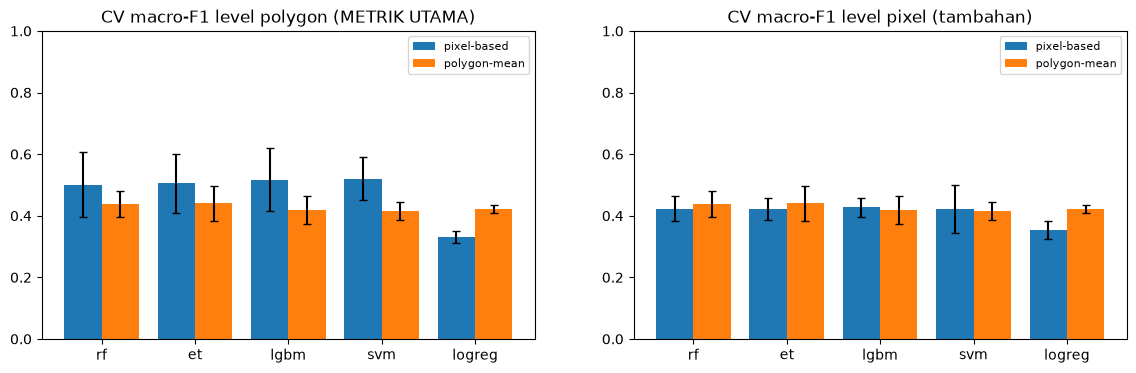

DATA AKTUAL PROJECT: errorbar = std antar 5 fold


In [16]:
# DATA AKTUAL PROJECT — plot 1-2: CV polygon-F1 dan pixel-F1 per model x metode.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ORD = ["rf", "et", "lgbm", "svm", "logreg"]
dp = pd.read_csv("../outputs/tables/cv_pixel.csv")
dm = pd.read_csv("../outputs/tables/cv_mean.csv")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, title in [(axes[0], "polygon_f1", "CV macro-F1 level polygon (METRIK UTAMA)"), (axes[1], "pixel_f1", "CV macro-F1 level pixel (tambahan)")]:
    mp = dp.groupby("model")[col].agg(["mean", "std"]).reindex(ORD)
    mm = dm.groupby("model")[col].agg(["mean", "std"]).reindex(ORD)
    x = np.arange(len(ORD))
    ax.bar(x - 0.2, mp["mean"], 0.4, yerr=mp["std"], label="pixel-based", capsize=3)
    ax.bar(x + 0.2, mm["mean"], 0.4, yerr=mm["std"], label="polygon-mean", capsize=3)
    ax.set_xticks(x, ORD)
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
plt.savefig("../outputs/figures/cv_f1_bars.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"DATA AKTUAL PROJECT: errorbar = std antar {N_SPLITS} fold")

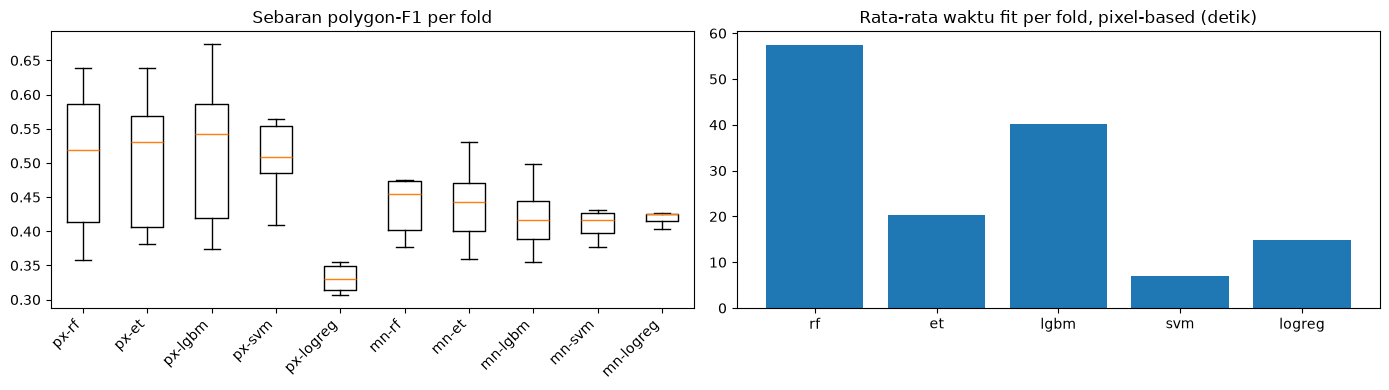

In [20]:
# DATA AKTUAL PROJECT — plot 3: sebaran per-fold + waktu training.
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Susun data dan label secara sinkron
label_all = [f"px-{m}" for m in ORD] + [f"mn-{m}" for m in ORD]
data = (
    [dp[dp["model"] == m]["polygon_f1"].values for m in ORD]
    + [dm[dm["model"] == m]["polygon_f1"].values for m in ORD]
)

axes[0].boxplot(data, showfliers=False)
axes[0].set_xticks(range(1, len(label_all) + 1))
axes[0].set_xticklabels(label_all, rotation=45, ha="right")
axes[0].set_title("Sebaran polygon-F1 per fold")

ft = dp.groupby("model")["fit_s"].mean().reindex(ORD)
axes[1].bar(ORD, ft.values)
axes[1].set_title("Rata-rata waktu fit per fold, pixel-based (detik)")

plt.tight_layout()
plt.savefig("../outputs/figures/cv_spread_time.png", dpi=110, bbox_inches="tight")
plt.show()

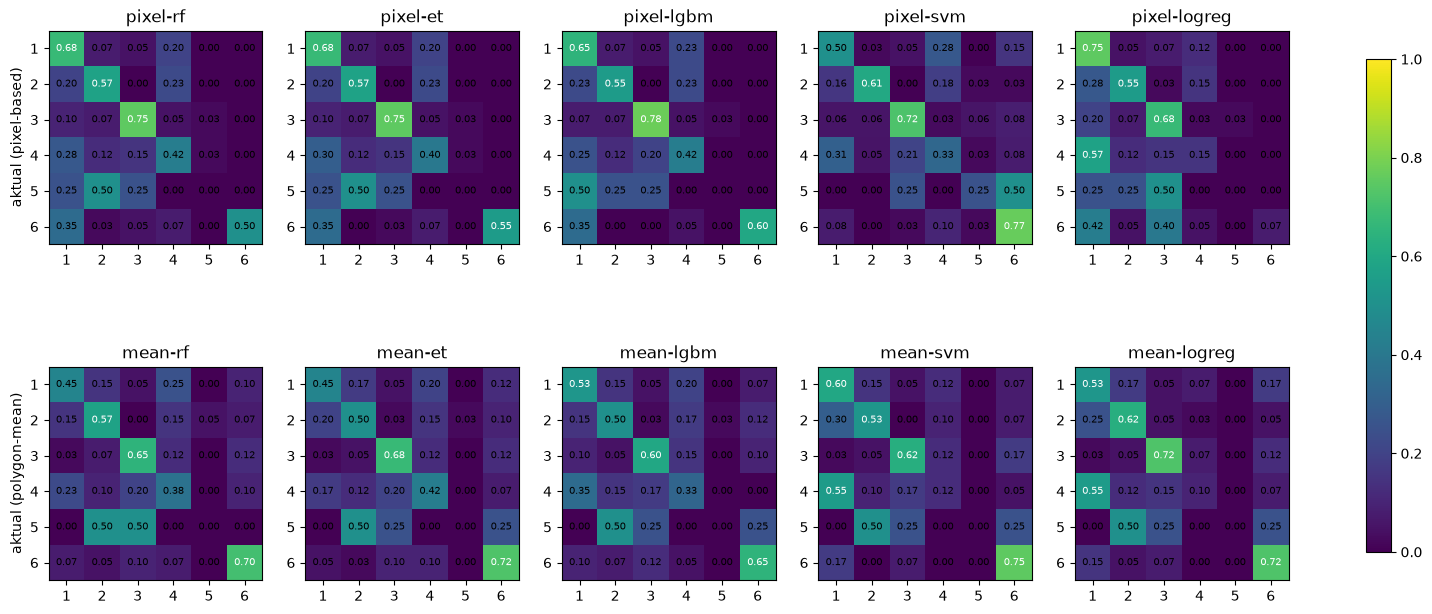

DATA AKTUAL PROJECT: dinormalisasi per baris (recall); label 1-6


In [21]:
# DATA AKTUAL PROJECT — plot 4: confusion matrix OOF level polygon (10 kombinasi).
import itertools

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for j, name in enumerate(ORD):
    for i, (tag, RESX) in enumerate([("pixel", RES), ("mean", RESM)]):
        prs = RESX[name]["best"]["pairs"]
        yt = [a for a, _ in prs]
        yp = [b for _, b in prs]
        cm = confusion_matrix(yt, yp, labels=[1, 2, 3, 4, 5, 6], normalize="true")
        ax = axes[i, j]
        im = ax.imshow(cm, vmin=0, vmax=1)
        ax.set_title(f"{tag}-{name}")
        ax.set_xticks(range(6), [1, 2, 3, 4, 5, 6])
        ax.set_yticks(range(6), [1, 2, 3, 4, 5, 6])
        for a, b in itertools.product(range(6), range(6)):
            ax.text(b, a, f"{cm[a, b]:.2f}", ha="center", va="center", fontsize=7,
                      color="white" if cm[a, b] > 0.5 else "black")
axes[0, 0].set_ylabel("aktual (pixel-based)")
axes[1, 0].set_ylabel("aktual (polygon-mean)")
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.savefig("../outputs/figures/oof_confusion.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"DATA AKTUAL PROJECT: dinormalisasi per baris (recall); label 1-6")

DATA AKTUAL PROJECT: importance dinormalisasi (RF/ET=LGBM tertimbang; SVM/LogReg linear tidak ditampilkan)


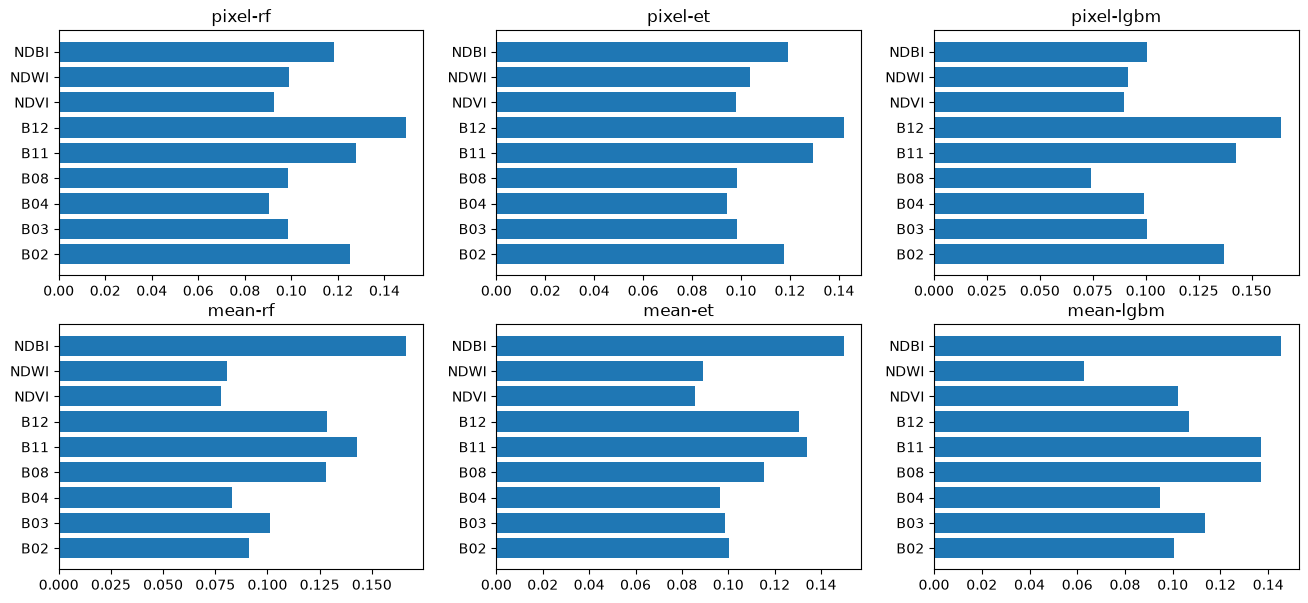

In [22]:
# DATA AKTUAL PROJECT — plot 5: feature importance model tree terbaik per metode.
import joblib
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for i, (tag, RESX) in enumerate([("pixel", RES), ("mean", RESM)]):
    for j, name in enumerate(["rf", "et", "lgbm"]):
        mdl = joblib.load(f"../outputs/models/{tag}_{name}.pkl")
        imp = np.asarray(mdl.feature_importances_)
        ax = axes[i, j]
        ax.barh(FEATS, imp / imp.sum())
        ax.set_title(f"{tag}-{name}")
print(f"DATA AKTUAL PROJECT: importance dinormalisasi (RF/ET=LGBM tertimbang; SVM/LogReg linear tidak ditampilkan)")
plt.savefig("../outputs/figures/feat_importance.png", dpi=110, bbox_inches="tight")
plt.show()

**Interpretasi visual:** errorbar (std 5 fold, mean 4 fold) bertumpang tindih — selisih kecil antar model bukan bukti. Confusion OOF (recall per baris): Mangrove tertinggi (0,68–0,78); Lahan hijau bocor ke Sawah (s.d. 0,57 pada logreg); Laut pixel-based sering tertukar Bangunan (0,50) — konsisten dengan 4 polygon train dan kotak Laut yang lebar; Danau 0,50–0,77. Importance ternormalisasi: SWIR B11/B12 + NDBI dominan di kedua metode, NIR (B08) menengah — dibaca sebagai kontribusi model, bukan klaim fisika.

## 4.6 Simpan model terbaik + metadata

Pemenang = skor CV polygon-F1 tertinggi (bila seri dalam std, pilih yang lebih sederhana dan nyatakan). RF terbaik selalu disimpan (syarat tugas).

In [23]:
# DATA AKTUAL PROJECT — 4.6 pemenang + best_model.pkl + random_forest_best.pkl + metadata JSON.
import datetime
import json
import shutil

import joblib
import lightgbm
import pandas as pd
import sklearn

score = {(tag, m): R["best"]["mean_polygon_f1"] for tag, RX in [("pixel", RES), ("mean", RESM)] for m, R in RX.items()}
win = max(score, key=score.get)
print(f"DATA AKTUAL PROJECT: pemenang = {win} skor={score[win]:.3f}")
shutil.copy(f"../outputs/models/{win[0]}_{win[1]}.pkl", "../outputs/models/best_model.pkl")
rfscore = {t: RESX["rf"]["best"]["mean_polygon_f1"] for t, RESX in [("pixel", RES), ("mean", RESM)]}
rftag = max(rfscore, key=rfscore.get)
shutil.copy(f"../outputs/models/{rftag}_rf.pkl", "../outputs/models/random_forest_best.pkl")
print(f"DATA AKTUAL PROJECT: RF terbaik = {rftag} skor={rfscore[rftag]:.3f}; sama_dengan_best = {rftag == win[0] and 'rf' == win[1]}")
meta = {"best": list(win), "best_cv_polygon_f1": round(score[win], 4),
        "features": FEATS, "class_mapping": {1: "Sawah", 2: "Bangunan / Permukiman", 3: "Mangrove", 4: "Lahan hijau", 5: "Laut", 6: "Danau"},
        "pixel_rule": "centroid (all_touched=False)", "cap_500": True, "cap_rng": "RandomState(42) urut fid",
        "mean_index_def": "indeks dari mean band", "nodata": -32768, "index_formulas": "NDVI=(B08-B04)/(B08+B04); NDWI=(B03-B08)/(B03+B08); NDBI=(B11-B08)/(B11+B08)",
        "svm_subsample": "8000 stratified seed 42 (pixel train saja)", "random_state": 42, "cv": "StratifiedGroupKFold group=FID (5 fold pixel-based; 4 fold polygon-mean, adaptasi Laut 4 polygon)",
        "libraries": {"sklearn": sklearn.__version__, "lightgbm": lightgbm.__version__},
        "tanggal": datetime.datetime.now().isoformat(timespec="seconds")}
with open("../outputs/models/metadata.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)
print("DATA AKTUAL PROJECT: tersimpan best_model.pkl + random_forest_best.pkl + metadata.json")

DATA AKTUAL PROJECT: pemenang = ('pixel', 'svm') skor=0.537
DATA AKTUAL PROJECT: RF terbaik = pixel skor=0.507; sama_dengan_best = False
DATA AKTUAL PROJECT: tersimpan best_model.pkl + random_forest_best.pkl + metadata.json


## Checkpoint Tahap 4

- 10 kombinasi (5 model × 2 metode) terlatih, tanpa ada yang dilewati.
- Hasil CV tersimpan (`cv_pixel.csv`, `cv_mean.csv`); pemenang dipilih dari CV training.
- Test set tidak dipakai untuk tuning maupun skor (hanya dihitung jumlahnya di 4.1).
- Model tersimpan (10 berkas) + `best_model.pkl` (pixel-svm) + `random_forest_best.pkl` (pixel-rf) + `metadata.json`.
- Adaptasi tercatat: mean memakai 4 fold; SVM pixel memakai subsample 8.861 (stratified, seed 42).